# Redes neuronales densamente conectadas — PyTorch

Este notebook es el **espejo exacto** del notebook de TensorFlow/Keras.
Mismo dataset, mismo modelo, misma tarea — distinta filosofía.

| | TensorFlow / Keras | PyTorch |
|---|---|---|
| Definir modelo | `tf.keras.Sequential([...])` | Clase que hereda `nn.Module` |
| Bucle de entrenamiento | `model.fit()` lo hace todo | Tú lo escribes a mano |
| Gradientes | Automáticos e invisibles | `loss.backward()` explícito |
| Datos | numpy arrays directos | `DataLoader` + `Dataset` |
| Filosofía | "dime qué quieres" | "dime cómo hacerlo" |

## 1 — Imports

PyTorch separa sus módulos: `torch` (tensores), `torch.nn` (capas), `torch.optim` (optimizadores).

In [1]:
import torch
import torch.nn as nn                       # capas, losses, activaciones
import torch.optim as optim                 # optimizadores (Adam, SGD...)
from torch.utils.data import DataLoader, TensorDataset  # manejo de datos

import numpy as np # para manipulación de arrays
import matplotlib.pyplot as plt # para visualización
from torchvision import datasets, transforms  # datasets estándar (como tf.keras.datasets)

print(f"PyTorch version: {torch.__version__}")

# PyTorch necesita saber en qué dispositivo trabajar (CPU o GPU)
# En TensorFlow esto es automático — aquí lo declaramos explícitamente
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

PyTorch version: 2.5.1+cu121
Dispositivo: cuda


## 2 — Cargar el dataset MNIST

**PyTorch:** usa `torchvision.datasets.MNIST` → devuelve un objeto `Dataset`.
Luego necesitas un `DataLoader` que sirve los datos en *batches* durante el entrenamiento.

In [3]:
# transform: aplana (28x28 → 784) y normaliza (0-255 → 0-1)
transform = transforms.Compose([
    transforms.ToTensor(), # convierte a tensor y normaliza a [0,1]
    transforms.Lambda(lambda x: x.view(-1)) # aplana: (1,28,28) → (784,)
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform) # descarga y prepara el dataset de entrenamiento
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform) # descarga y prepara el dataset de testeo

# DataLoader: sirve los datos en batches y los mezcla aleatoriamente
#schuffle=True en entrenamiento para mezclar los datos, shuffle=False en testeo para mantener el orden
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} imágenes | Test: {len(test_dataset)} imágenes")
print(f"Batches por epoch: {len(train_loader)}")

# Inspeccionar un batch
x_batch, y_batch = next(iter(train_loader)) 
print(f"Shape de un batch: {x_batch.shape} → (batch_size=64, features=784)")

Train: 60000 imágenes | Test: 10000 imágenes
Batches por epoch: 938
Shape de un batch: torch.Size([64, 784]) → (batch_size=64, features=784)


## 3 — Visualización

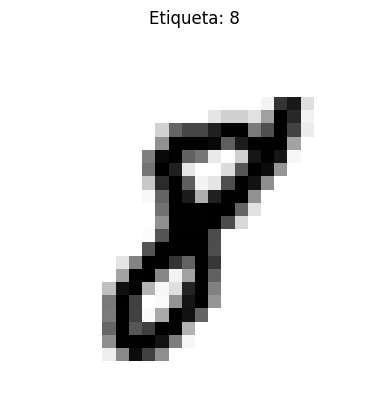

In [4]:
# Buscar el primer '8' en el dataset
for img, label in train_dataset:
    if label == 8:
        sample_img = img
        break

plt.imshow(sample_img.view(28, 28), cmap=plt.cm.binary)
plt.title("Etiqueta: 8")
plt.axis("off")
plt.show()

## 4 — Definición del modelo

Aquí está **la diferencia más importante** entre los dos frameworks.

**Keras:**
```python
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="softmax", input_shape=(784,))
])
```

**PyTorch:** defines una clase con dos métodos obligatorios:
- `__init__`: declara las capas (sus pesos, pero no la lógica)
- `forward`: describe exactamente cómo fluyen los datos capa a capa

Esto te da control total: puedes para poner condicionales, bucles, múltiples salidas o cualquier cosa que Python permita.

In [ ]:
class ClasificadorLineal(nn.Module):  # hereda de nn.Module (equivale a keras.Model)

    def __init__(self):
        super().__init__()
        # Declaramos las capas — igual que las líneas dentro de Sequential([...])
        # nn.Linear(in, out) = tf.keras.layers.Dense(out, input_shape=(in,))
        self.output = nn.Linear(784, 10)  # 784 entradas, 10 salidas

    def forward(self, x):
        # Describes el camino de los datos: entrada y salida
        x = self.output(x) # capa lineal
        x = torch.softmax(x, dim=1) # activación softmax
        return x

model = ClasificadorLineal().to(device)  # .to(device) envía el modelo a GPU si hay

# Equivalente a model.summary() de Keras
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parámetros: {total_params:,}")
print("  784 entradas × 10 neuronas = 7,840 pesos")
print("  + 10 bias = 7,850 parámetros  ← igual que en Keras")

ClasificadorLineal(
  (output): Linear(in_features=784, out_features=10, bias=True)
)

Total parámetros: 7,850
  784 entradas × 10 neuronas = 7,840 pesos
  + 10 bias = 7,850 parámetros  ← igual que en Keras


## 5 — Compilación: loss + optimizador

**Keras:** `model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])`

**PyTorch:** defines loss y optimizador como objetos separados, fuera del modelo.
Esto es más explícito — en Keras estaban "dentro" del modelo después de compile().

In [ ]:
# Loss: CrossEntropyLoss de PyTorch incluye el softmax internamente
# NOTA: en la práctica el forward() suele devolver logits sin softmax
# Aquí lo dejamos con softmax explícito para que sea comparable con Keras
criterion = nn.CrossEntropyLoss() # equivale a sparse_categorical_crossentropy

# Optimizador: recibe los parámetros del modelo que debe actualizar
optimizer = optim.Adam(model.parameters(), lr=0.001) # equivale a Adam(learning_rate=0.001)

print("Loss:       ", criterion)
print("Optimizador:", optimizer)

Loss:        CrossEntropyLoss()
Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 6 — Bucle de entrenamiento

**Esta es la diferencia más grande y más reveladora.**

En Keras, `model.fit()` oculta todo este proceso.
En PyTorch lo escribes tú, y entiendes exactamente qué ocurre en cada paso:

1. **Forward pass**: los datos pasan por el modelo y se obtiene una predicción
2. **Cálculo del loss**: cuánto se equivocó el modelo
3. **Backward pass**: se calculan los gradientes (derivadas del loss respecto a cada peso)
4. **Update**: el optimizador ajusta los pesos en la dirección del gradiente
5. **zero_grad**: se borran los gradientes para el siguiente batch (si no se acumulan)

In [7]:
def train_epoch(model, loader, criterion, optimizer):
    """Una pasada completa por el dataset de entrenamiento (= 1 epoch)."""
    model.train()  # activa modo entrenamiento (habilita dropout, batchnorm, etc.)
    total_loss, correct, total = 0, 0, 0

    for x_batch, y_batch in loader:  # itera sobre todos los batches
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # Paso 1: borrar gradientes del batch anterior
        # (Keras lo hace automáticamente — aquí es explícito)
        optimizer.zero_grad()

        # Paso 2: forward pass — obtener predicciones
        y_pred = model(x_batch)

        # Paso 3: calcular el loss
        loss = criterion(y_pred, y_batch)

        # Paso 4: backward pass — calcular gradientes
        # (Keras llama esto internamente en cada batch)
        loss.backward()

        # Paso 5: actualizar pesos con los gradientes
        optimizer.step()

        # Acumular métricas
        total_loss += loss.item() * x_batch.size(0)
        correct    += (y_pred.argmax(dim=1) == y_batch).sum().item()
        total      += x_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluación sobre test/validation set — sin calcular gradientes."""
    model.eval()   # desactiva dropout, batchnorm en modo inferencia
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():  # equivale a tf.stop_gradient — ahorra memoria
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model(x_batch)
            loss   = criterion(y_pred, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            correct    += (y_pred.argmax(dim=1) == y_batch).sum().item()
            total      += x_batch.size(0)

    return total_loss / total, correct / total


# ---- Entrenamiento: 5 epochs (igual que en Keras) ----
EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"loss: {train_loss:.4f}  acc: {train_acc:.4f}  "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

Epoch 1/5  loss: 1.6910  acc: 0.8457  val_loss: 1.5894  val_acc: 0.9080
Epoch 2/5  loss: 1.5830  acc: 0.9062  val_loss: 1.5666  val_acc: 0.9165
Epoch 3/5  loss: 1.5664  acc: 0.9149  val_loss: 1.5574  val_acc: 0.9200
Epoch 4/5  loss: 1.5580  acc: 0.9195  val_loss: 1.5515  val_acc: 0.9231
Epoch 5/5  loss: 1.5525  acc: 0.9226  val_loss: 1.5478  val_acc: 0.9251


## 7 — Detección de overfitting (misma gráfica que en Keras)

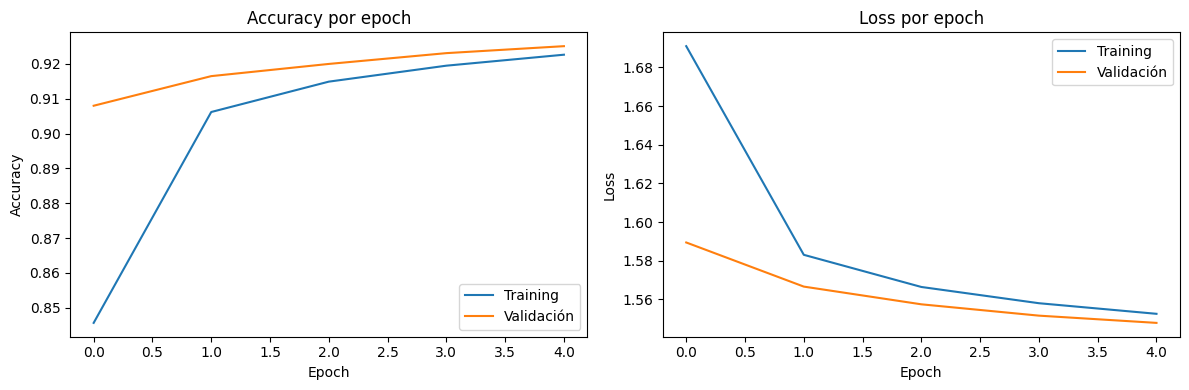

Training:   0.9226
Validación: 0.9251
Gap:        -0.0025  OK - sin overfitting


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_acc"], label="Training")
ax1.plot(history["val_acc"],   label="Validación")
ax1.set_title("Accuracy por epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(history["train_loss"], label="Training")
ax2.plot(history["val_loss"],   label="Validación")
ax2.set_title("Loss por epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

train_acc = history["train_acc"][-1]
val_acc   = history["val_acc"][-1]
print(f"Training:   {train_acc:.4f}")
print(f"Validación: {val_acc:.4f}")
print(f"Gap:        {train_acc - val_acc:.4f}  ", end="")
print("OK - sin overfitting" if (train_acc - val_acc) < 0.02 else "Posible overfitting")

## 8 — Visualizar pesos aprendidos

Misma visualización que en Keras con `model.get_weights()[0]`.
En PyTorch accedemos a los pesos con `model.output.weight`.

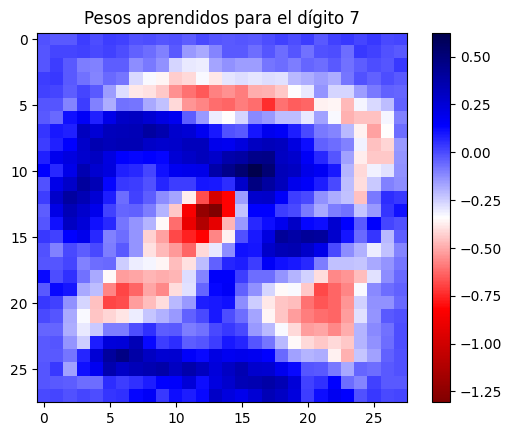

In [9]:
def plot_learned_weights(model, digit: int) -> None:
    """Visualiza los pesos aprendidos para un dígito concreto."""
    # En Keras: model.get_weights()[0]  shape: (784, 10)
    # En PyTorch: model.output.weight   shape: (10, 784)  ← traspuesta!
    weights = model.output.weight.detach().cpu().numpy()  # (10, 784)
    weight_map = weights[digit].reshape(28, 28)           # fila del dígito → 28x28

    plt.figure()
    plt.imshow(weight_map, cmap="seismic_r")
    plt.title(f"Pesos aprendidos para el dígito {digit}")
    plt.colorbar()
    plt.show()

plot_learned_weights(model, digit=7)

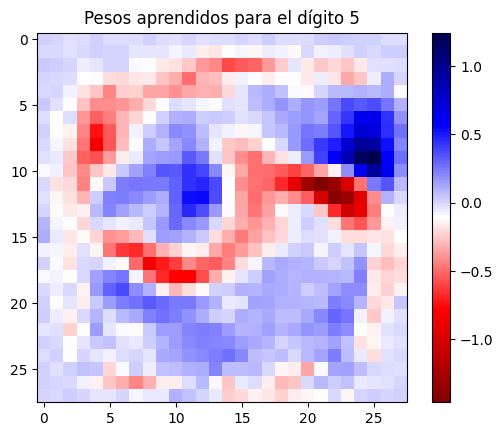

In [10]:
plot_learned_weights(model, digit=5)

## 9 — Comparativa final: Keras vs PyTorch

| Aspecto | TensorFlow / Keras | PyTorch |
|---|---|---|
| Líneas de código | ~20 | ~60 |
| Bucle de entrenamiento | automático (`fit`) | manual (tú lo escribes) |
| Gradientes | invisibles | `loss.backward()` explícito |
| Acceso a pesos | `get_weights()[0]` shape `(784,10)` | `.weight` shape `(10,784)` |
| Envío a GPU | automático | `.to(device)` manual |
| `model.eval()` | implícito | explícito (importante con Dropout) |
| `torch.no_grad()` | no existe | necesario para inferencia eficiente |
| Resultado esperado | ~92% accuracy | ~92% accuracy |

**Conclusión:** PyTorch es más verboso pero más transparente.
Entender este bucle manual es la clave para después poder modificar
el entrenamiento de formas que Keras no permite fácilmente
(custom losses, gradient clipping, training loops complejos, etc.).